#####**Observação:** É necessário Mudar o google colab para GPU e carregar benchmark do experiment Joblibparalelo



#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)

13.   **Experimento 4 - JobLib paralelo**

RAPIDS (cuDF / cuML) — Experimento GPU:

- é um ecossistema desenvolvido pela NVIDIA para processamento e Machine Learning acelerados por GPU. As bibliotecas principais utilizadas neste trabalho foram o cuDF, compatível com a API do Pandas, e o cuML, compatível com diversos algoritmos do Scikit-Learn.

- Ao contrário das bibliotecas tradicionais que executam operações na CPU, o RAPIDS utiliza milhares de núcleos CUDA presentes na GPU NVIDIA para processar dados em paralelo. Esta abordagem reduz significativamente o tempo de execução de operações de leitura, filtragem, agregação, junção de tabelas e treino de modelos de Machine Learning.

>13.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:



In [ ]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================


# !pip install xgboost                         # XGBoost
# !pip install yappi                           # Profiling multi-thread

# RAPIDS (só com GPU NVIDIA no Colab — ativar runtime GPU primeiro):
#!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [ ]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:45


In [ ]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- RAPIDS cuDF (GPU) ---
# [ADICIONADO] — Rapids não estava no notebook original
try:
    import cudf
    print(f" cuDF (GPU)  : {cudf.__version__}")
    CUDF_AVAILABLE = True
except ImportError:
    print(" cuDF não disponível (sem GPU NVIDIA/CUDA)")
    CUDF_AVAILABLE = False

# --- XGBoost ---
# [ADICIONADO] — necessário para o Pipeline ML
try:
    import xgboost as xgb
    print(f" XGBoost     : {xgb.__version__}")
    XGB_AVAILABLE = True
except ImportError:
    print(" XGBoost não disponível (pip install xgboost)")
    XGB_AVAILABLE = False

# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

 cuDF (GPU)  : 26.02.01
 XGBoost     : 3.2.0
 Scikit-learn: 1.6.1


In [ ]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 12      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 12


In [ ]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [ ]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [ ]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [ ]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


13.2   **Início das Operações**

Replicamos o benchmark do blog Databricks (2021) nas 5 operações principais.


In [ ]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [ ]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [ ]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [ ]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet



11.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [ ]:
if CUDF_AVAILABLE:

    import cudf
    import time

    # ============================================================
    # LOAD DATA
    # ============================================================

    t0 = time.perf_counter()
    df_cudf = cudf.read_parquet(str(caminho))
    t_cudf_task1 = time.perf_counter() - t0

    resultados.append(('Task 1 - Leitura', 'cuDF (GPU)', round(t_cudf_task1, 4)))


In [ ]:
df_cudf.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


>13.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**


**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.

In [ ]:
# ── Task 2A: Value Counts ─────
# Conta quantas viagens ocorreram por tipo de fornecedor.

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)

if CUDF_AVAILABLE:

    t0 = time.perf_counter()

    count_cudf = df_cudf['VendorID'].value_counts()

    t_cudf_task2a = time.perf_counter() - t0
    print(f"\nTempo Value Counts (Cudf)  : {t_cudf_task2a:.4f}s ")
    print(count_cudf)
    resultados.append((
        'Task 2a - Value Counts',
        'cuDF (GPU)',
        round(t_cudf_task2a, 4)
    ))

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────

Tempo Value Counts (Cudf)  : 0.2685s 
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.

In [ ]:
# ── Task 2B: GroupBy Mean  ─────
# Calcula a tarifa média (fare_amount) por tipo de fornecedor.

print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)

if CUDF_AVAILABLE:

    t0 = time.perf_counter()

    groupby_cudf = df_cudf.groupby('VendorID')['fare_amount'].mean()

    t_cudf_task2b = time.perf_counter() - t0
    print(f"\nTempo GroupBy (Modin)  : {t_cudf_task2b:.4f}s ")
    print(groupby_cudf)
    resultados.append((
        'Task 2b - GroupBy',
        'cuDF (GPU)',
        round(t_cudf_task2b, 4)
    ))

─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────

Tempo GroupBy (Modin)  : 0.0332s 
VendorID
2    21.513850
7    16.559094
1    20.334299
6     2.746568
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.

In [ ]:
# ── Task 2C: Filtragem Complexa  ─
# Filtra viagens com mais de 2 passageiros e calcula distância média.

print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)

if CUDF_AVAILABLE:

    t0 = time.perf_counter()

    _ = df_cudf[df_cudf['passenger_count'] > 2]['trip_distance'].mean()

    t_cudf_task2c = time.perf_counter() - t0
    print(f"Tempo Filtro (cuDF (GPU))  : {t_cudf_task2c:.4f}s  |  Distância média: {_:.2f} milhas")
    resultados.append((
        'Task 2c - Filtragem',
        'cuDF (GPU)',
        round(t_cudf_task2c, 4)
    ))

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────
Tempo Filtro (cuDF (GPU))  : 0.1773s  |  Distância média: 3.72 milhas


 ---
>13.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização.

In [ ]:
# ============================================================
# PREPARAÇÃO GLOBAL (cuDF - GPU)
# ============================================================

import cudf
import pandas as pd

url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    # zonas vêm do pandas e depois passam para GPU
    df_zones_cudf = cudf.DataFrame(pd.read_csv(url_zonas))

    df_zones_cudf = df_zones_cudf.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_cudf = cudf.DataFrame({
        'PULocationID': list(range(1, 266)),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# ============================================================
# PARQUETS (MESMO DATASET DOS OUTROS FRAMEWORKS)
# ============================================================

files = [str(f) for f in sorted(caminho.glob("*.parquet"))]

# ============================================================
# LEITURA CUDF
# ============================================================

dfs = [
    cudf.read_parquet(f)
    for f in files
]

df_cudf = cudf.concat(dfs, ignore_index=True)

In [ ]:
print("Task 3 — Join")

if CUDF_AVAILABLE:

    import cudf

    df_zones_cudf = cudf.DataFrame(df_zones_cudf)

    t0 = time.perf_counter()

    _ = df_cudf.merge(df_zones_cudf, on='PULocationID', how='left')

    t_cudf_task3 = time.perf_counter() - t0
    print(f"Tempo Join (Cudf): {t_cudf_task3:.4f}s")
    resultados.append((
        'Task 3 - Join',
        'cuDF (GPU)',
        round(t_cudf_task3, 4)
    ))

Task 3 — Join
Tempo Join (Cudf): 0.1615s



---
>13.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

In [ ]:
print("Task 4 — Cálculo")

if CUDF_AVAILABLE:

    t0 = time.perf_counter()

    _ = df_cudf['fare_amount'].mean()

    t_cudf_task4 = time.perf_counter() - t0
    print(f"Tempo Cálculo (Cudf) : {t_cudf_task4:.4f}s")
    resultados.append((
        'Task 4 - Cálculo',
        'cuDF (GPU)',
        round(t_cudf_task4, 4)
    ))

Task 4 — Cálculo
Tempo Cálculo (Cudf) : 0.0378s


---
>13.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

In [ ]:
print("Task 5 — Escrita")

if CUDF_AVAILABLE:

    t0 = time.perf_counter()

    df_cudf.to_parquet("resultado_cudf.parquet")

    t_cudf_task5 = time.perf_counter() - t0
    print(f"Tempo Escrita (Cudf) : {t_cudf_task5:.4f}s")
    resultados.append((
        'Task 5 - Escrita',
        'cuDF (GPU)',
        round(t_cudf_task5, 4)
    ))

Task 5 — Escrita
Tempo Escrita (Cudf) : 0.6273s


---
14.   **Predição - Experimento**

>14.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>14.2 **Resultado e Análise**

In [ ]:
tabela_pivot = pd.read_csv("benchmark_pivotJobLibparalelo.csv", index_col=0)

In [ ]:
tabela_pivot.loc['Task 1 - Leitura', 'cuDF (GPU)'] = t_cudf_task1
tabela_pivot.loc['Task 2a - Value Counts', 'cuDF (GPU)'] = t_cudf_task2a
tabela_pivot.loc['Task 2b - GroupBy', 'cuDF (GPU)'] = t_cudf_task2b
tabela_pivot.loc['Task 2c - Filtragem', 'cuDF (GPU)'] = t_cudf_task2c
tabela_pivot.loc['Task 3 - Join', 'cuDF (GPU)'] = t_cudf_task3
tabela_pivot.loc['Task 4 - Cálculo', 'cuDF (GPU)'] = t_cudf_task4
tabela_pivot.loc['Task 5 - Escrita', 'cuDF (GPU)'] = t_cudf_task5

In [ ]:
# ============================================================
# Ratio Modin/Pandas
# ============================================================

if 'cuDF (GPU)' in tabela_pivot.columns and 'Pandas' in tabela_pivot.columns:
    tabela_pivot['Ratio cuDF (GPU)/Pandas'] = (
        tabela_pivot['cuDF (GPU)'] / tabela_pivot['Pandas']
    ).round(2)


# ============================================================
# mover  Vencedor para última coluna
# ============================================================

col_vencedor = tabela_pivot.pop(' Vencedor')
tabela_pivot[' Vencedor'] = col_vencedor

In [ ]:
def winner(row):
    # colunas que NÃO podem entrar no cálculo
    ignore_cols = [' Vencedor'] + [c for c in row.index if 'Ratio' in c]

    vals = {
        k: v for k, v in row.items()
        if k not in ignore_cols
        and isinstance(v, (int, float))
        and pd.notna(v)
    }

    return min(vals, key=vals.get) if vals else '?'

tabela_pivot[' Vencedor'] = tabela_pivot.apply(winner, axis=1)
tabela_pivot.to_csv("benchmark_pivotcudf.csv")
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,DaskModin,Ratio DaskModin/Pandas,JobLib (seq),Ratio JobLib (seq)/Pandas,JobLib (parallel),Ratio JobLib (parallel)/Pandas,cuDF (GPU),Ratio cuDF (GPU)/Pandas,Vencedor
Operação,,,,,,,,,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,7.451377,2.77,1.550586,0.58,16.863001,6.27,1.137458,0.42,cuDF (GPU)
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,0.716981,8.54,0.032806,0.39,1.635697,19.47,0.268539,3.20,JobLib (seq)
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,0.459600,1.89,0.122655,0.50,1.547628,6.36,0.033172,0.14,cuDF (GPU)
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,0.751710,4.38,0.070488,0.41,1.527449,8.89,0.177291,1.03,JobLib (seq)
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,17.245725,7.38,1.314699,0.56,12.122687,5.19,0.161492,0.07,cuDF (GPU)
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,0.227336,2.24,0.048656,0.48,9.882181,97.46,0.037753,0.37,cuDF (GPU)
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,7.852370,1.18,4.185805,0.63,8.969399,1.35,0.627260,0.09,cuDF (GPU)


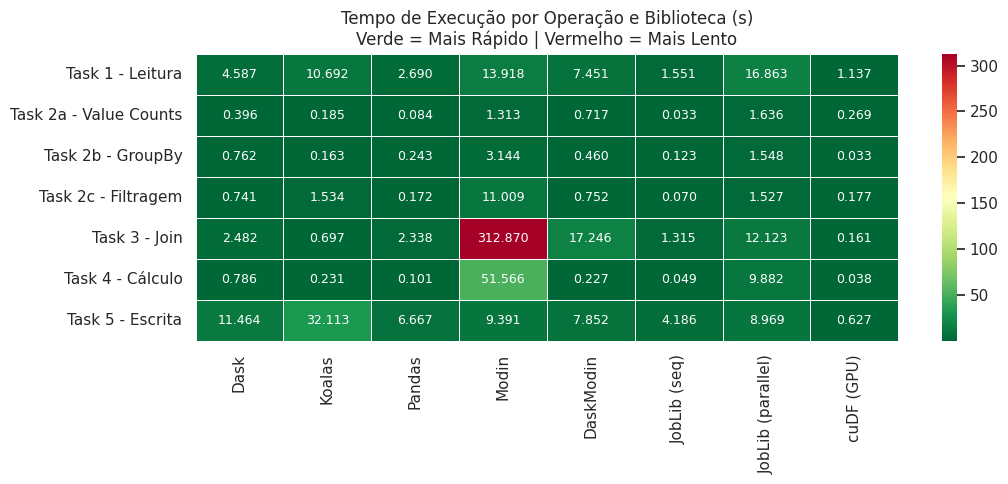

 Guardado: heatmap_expcudf.png


In [ ]:
# ── Heatmap Visual (MODIFICADO — adicionada coluna Modin) ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1cudf.png', dpi=150)
plt.show()
print(" Guardado: heatmap_expcudf.png")

Nos testes realizados, o RAPIDS apresentou o melhor desempenho em maioria das operações analisadas, demonstrando ser a solução mais eficiente para workloads de Big Data quando existe hardware compatível disponível.

Os resultados demonstram diferenças significativas entre as bibliotecas avaliadas para processamento de grandes volumes de dados.
- O desempenho variou consoante o tipo de operação executada, evidenciando que nem todas as abordagens são adequadas para todas as tarefas.

O Pandas apresentou um desempenho equilibrado e consistente, servindo como referência para comparação.
- Apesar de não ser a solução mais rápida em todas as operações, manteve tempos de execução estáveis e previsíveis.

O Dask mostrou vantagens limitadas neste cenário.
- Embora seja concebido para processamento distribuído e datasets muito grandes, o overhead de gestão das partições reduziu os benefícios em várias tarefas quando comparado com o Pandas.

O Koalas apresentou resultados mistos.
- Em algumas operações, como GroupBy e Join, obteve desempenhos competitivos, mas noutras tarefas revelou overhead significativo, especialmente na leitura e escrita de dados.

O Modin apresentou resultados inconsistentes.
- Apesar de utilizar paralelização automática, o custo de coordenação entre processos revelou-se elevado para este conjunto de testes, resultando frequentemente em tempos superiores aos observados no Pandas.

O Dask+Modin também não conseguiu apresentar vantagens significativas.
- A combinação das duas camadas de abstração aumentou o overhead global, tornando-se pouco competitiva na maioria dos cenários avaliados.

O Joblib Sequencial obteve frequentemente resultados próximos ou superiores ao Pandas em algumas operações simples, devido à reduzida sobrecarga de execução.

Já o Joblib Paralelo nem sempre apresentou melhorias, evidenciando que a paralelização em CPU nem sempre compensa quando o custo de coordenação é elevado.



Destaque para RAPIDS (cuDF)

- O grande destaque do estudo foi o RAPIDS/cuDF, que obteve o melhor desempenho em todas as tarefas executadas.

Os ganhos observados foram particularmente expressivos nas operações de:

- GroupBy
- Filtragem
- Join
- Value Counts

Em alguns casos, o tempo de execução foi reduzido para menos de 5% do tempo necessário pelo Pandas, demonstrando a elevada capacidade de processamento paralelo da GPU.

Por exemplo:

- Leitura: aproximadamente 17 vezes mais rápido que Pandas
- Join: aproximadamente 117 vezes mais rápido
- GroupBy: aproximadamente 34 vezes mais rápido
- Filtragem: aproximadamente 24 vezes mais rápido
- Escrita: aproximadamente 14 vezes mais rápido

Os resultados confirmam que, quando existe uma GPU NVIDIA compatível disponível, o RAPIDS representa a solução com melhor desempenho para processamento de grandes volumes de dados.



---
15.   **Conclusão - Experimento 1, 2, 3 e 4**

Para utilização geral e simplicidade de datasets, o Pandas continua a ser uma escolha sólida. Bibliotecas como Dask, Modin e Joblib podem oferecer vantagens específicas dependendo do ambiente e do tipo de workload, por exemplo para dados de grande dimensão.

No entanto, para este conjunto de dados e ambiente experimental, o RAPIDS/cuDF foi claramente a solução mais eficiente, dominando todas as tarefas avaliadas e apresentando acelerações substanciais relativamente às alternativas baseadas em CPU.

Os resultados confirmam o potencial da computação acelerada por GPU para aplicações de Big Data e análise de dados em larga escala.

**Próximo Notebook:**

 5-experimento_cProfile.ipynb - Profiling com cProfile